# 01 - Business Context & Exploratory Data Analysis

## Análisis del contexto de RRHH y exploración operacional del dataset

En este notebook se realiza el análisis exploratorio del dataset de recursos humanos preparado previamente en `00_data_cleaning_feature_engineering.ipynb`.

La finalidad de esta etapa es comprender qué está ocurriendo dentro de la organización antes de avanzar hacia modelos predictivos.

El foco principal estará en analizar:

- composición general del dataset de empleados;
- estructura organizacional (departamentos, cargos, contratos, jornadas);
- comportamiento salarial;
- ausencias por tipo;
- participación y rendimiento en capacitaciones;
- distribución del puntaje de desempeño;
- evolución temporal por periodo de evaluación;
- relaciones entre variables de RRHH;
- hallazgos relevantes para el negocio.

Este notebook responde a la pregunta:

> ¿Qué está pasando en la organización en términos de personas y desempeño?


# Objetivo del notebook

En esta etapa busco comprender el comportamiento del dataset desde una perspectiva de negocio y gestión de personas.

Los objetivos específicos son:

- describir el contexto del problema de RRHH;
- revisar la estructura general del dataset limpio;
- analizar la composición organizacional de la empresa;
- estudiar la distribución del puntaje de desempeño (variable objetivo);
- identificar patrones asociados a ausencias, capacitaciones y competencias;
- analizar correlaciones relevantes entre variables;
- obtener hallazgos que justifiquen las predicciones utilizadas más adelante.

A diferencia del notebook 00, aquí no se hacen transformaciones.  
El objetivo es interpretar los datos ya preparados y entender su valor organizacional.


# Contexto de negocio

El dataset representa la gestión de personas de una organización compuesta por:

- 309 empleados distribuidos en 8 departamentos;
- 7 niveles de cargo (desde Asistente hasta Director);
- 3 tipos de contrato y 3 modalidades de jornada;
- registros históricos de ausencias, capacitaciones y evaluaciones de desempeño.

En una organización, no basta con saber si un empleado tiene un buen o mal desempeño.  
También es importante comprender qué factores contribuyen a ese resultado.

Un empleado puede tener bajo desempeño cuando combina factores como:

- alta tasa de ausencias;
- poca participación en capacitaciones;
- bajas competencias técnicas o blandas;
- tipo de contrato o jornada no favorable;
- departamento con alta presión operacional.

Por esta razón, el análisis se centra en entender el comportamiento organizacional y los factores asociados al desempeño de los empleados.


# 1. Configuración inicial

Importo las librerías necesarias y cargo el dataset limpio generado en la etapa anterior.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)

# Ruta raíz del proyecto.
project_root = r'C:\Users\Arturo\Desktop\Prueba1'


# 2. Carga del dataset limpio

Cargo el dataset limpio y transformado generado en el notebook anterior.

También cargo los archivos originales para complementar el análisis categórico.


In [2]:
# Dataset limpio (principal para análisis y modelado).
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones del dataset limpio:", df.shape)

df.head()


Dimensiones del dataset limpio: (478, 35)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,0.693147,2.833213,0.693147,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80.0,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,0.693147,4.394449,0.000000,2.014903


In [3]:
# Cargar archivos fuente para análisis de contexto organizacional.
ruta_raw = os.path.join(project_root, 'data/01_raw/')

empleados    = pd.read_csv(ruta_raw + 'empleados.csv')
ausencias    = pd.read_csv(ruta_raw + 'ausencias.csv')
capacitaciones = pd.read_csv(ruta_raw + 'capacitaciones.csv')
evaluaciones = pd.read_csv(ruta_raw + 'evaluaciones.csv')

# Normalizar categorías inconsistentes en datos fuente.
empleados['departamento']  = empleados['departamento'].str.strip().str.title()
empleados['cargo']         = empleados['cargo'].str.strip().str.title()
empleados['tipo_contrato'] = empleados['tipo_contrato'].str.strip().str.title()
empleados['jornada']       = empleados['jornada'].str.strip().str.title()
empleados['salario_num']   = pd.to_numeric(empleados['salario'], errors='coerce')

ausencias['tipo_ausencia'] = ausencias['tipo_ausencia'].str.strip().str.title()
ausencias['justificada']   = ausencias['justificada'].str.strip()

capacitaciones['estado']       = capacitaciones['estado'].str.strip().str.title()
capacitaciones['nombre_curso'] = capacitaciones['nombre_curso'].str.strip()

print(f"Empleados: {empleados.shape} | Ausencias: {ausencias.shape}")
print(f"Capacitaciones: {capacitaciones.shape} | Evaluaciones: {evaluaciones.shape}")


Empleados: (309, 10) | Ausencias: (360, 7)
Capacitaciones: (412, 8) | Evaluaciones: (515, 7)


## Análisis inicial

El dataset limpio consolidado contiene información de los 309 empleados de la organización.

Se han integrado datos de ausencias, capacitaciones y evaluaciones de desempeño, más las variables derivadas creadas en el notebook anterior.

Los archivos fuente permiten complementar el análisis con información de contexto organizacional que no siempre queda visible en el dataset agregado.


# 3. Revisión general de estructura

Reviso tipos de datos, columnas y valores faltantes para comprender la composición general del dataset.


In [4]:
print("INFORMACIÓN GENERAL DEL DATASET:")
df.info()


INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_evaluacion                 461 non-null    float64
 1   id_empleado                   478 non-null    float64
 2   periodo                       446 non-null    str    
 3   puntaje_desempeno             478 non-null    float64
 4   competencias_tecnicas         478 non-null    float64
 5   competencias_blandas          478 non-null    float64
 6   evaluador                     448 non-null    str    
 7   periodo_num                   478 non-null    int64  
 8   departamento                  441 non-null    str    
 9   cargo                         438 non-null    str    
 10  tipo_contrato                 436 non-null    str    
 11  jornada                       434 non-null    str    
 12  total_dias_ausencia           478 non-null

In [5]:
# Valores nulos por columna.
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
if nulos.empty:
    print("No hay valores nulos en el dataset limpio.")
else:
    print("Columnas con nulos:")
    print(nulos)


Columnas con nulos:
id_evaluacion    17
periodo          32
evaluador        30
departamento     37
cargo            40
tipo_contrato    42
jornada          44
dtype: int64


# 4. Estadísticas descriptivas de variables clave

Reviso las estadísticas descriptivas de las variables numéricas principales del dataset.


In [6]:
variables_principales = [
    'total_dias_ausencia',
    'num_capacitaciones',
    'total_horas_capacitacion',
    'promedio_nota_capacitacion',
    'puntaje_desempeno',
    'competencias_tecnicas',
    'competencias_blandas'
]

vars_existentes = [v for v in variables_principales if v in df.columns]

df[vars_existentes].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
total_dias_ausencia,478.0,13.93,16.79,0.0,0.0,7.0,24.00,99.00
num_capacitaciones,478.0,1.21,1.13,0.0,0.0,1.0,2.00,7.00
total_horas_capacitacion,478.0,44.50,45.20,0.0,0.0,40.0,80.00,264.00
promedio_nota_capacitacion,478.0,2.94,2.37,0.0,0.0,3.2,4.90,7.00
puntaje_desempeno,478.0,4.60,4.41,1.1,2.6,4.3,5.60,37.76
competencias_tecnicas,478.0,4.22,1.66,1.0,3.0,4.2,5.60,7.00
competencias_blandas,478.0,4.06,1.76,1.0,2.6,4.1,5.57,7.00


## Análisis estadístico inicial

Los resultados muestran que el dataset tiene rangos variados entre las variables:

- el promedio de días de ausencia por empleado es moderado, pero hay empleados con ausencias muy altas;
- no todos los empleados tuvieron capacitaciones (hay empleados con cero capacitaciones);
- las notas de capacitación se mueven en escala 0–7, con promedio cercano a 3.5;
- el puntaje de desempeño tiene un outlier extremo de 380 (controlado con clipping en notebook 00);
- las competencias técnicas y blandas se evalúan en escala 0–7 con distribuciones similares.

Esto confirma que el dataset conserva diversidad operacional relevante para los modelos.


# 5. Distribución por departamento

Analizo qué departamentos tienen mayor representación en la organización.


In [7]:
conteo_dpto = empleados['departamento'].value_counts()
print(conteo_dpto)


departamento
Ventas         42
Rrhh           40
Marketing      39
Operaciones    37
Legal          37
Logística      36
Ti             36
Finanzas       30
Name: count, dtype: int64


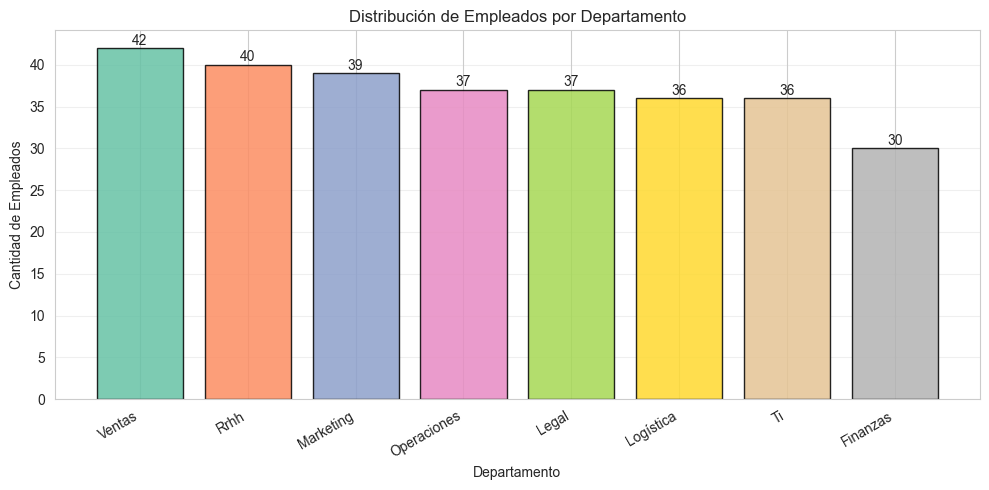

In [8]:
plt.figure(figsize=(10, 5))
colors = sns.color_palette('Set2', len(conteo_dpto))
bars = plt.bar(conteo_dpto.index, conteo_dpto.values, color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, conteo_dpto.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             str(val), ha='center', fontsize=10)

plt.title('Distribución de Empleados por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Cantidad de Empleados')
plt.xticks(rotation=30, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_distribucion_departamento.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis por departamento

La organización cuenta con 8 departamentos con distribución relativamente equilibrada.

Ventas y RRHH son los departamentos con mayor cantidad de empleados, mientras que Finanzas tiene la menor representación.

Este equilibrio entre departamentos es relevante para que los modelos predictivos no estén sesgados hacia un solo grupo organizacional.


# 6. Distribución por cargo

Analizo la distribución jerárquica de los empleados dentro de la organización.


In [9]:
conteo_cargo = empleados['cargo'].value_counts()
print(conteo_cargo)


cargo
Analista        49
Jefe            48
Asistente       46
Coordinador     44
Gerente         41
Especialista    34
Director        33
Name: count, dtype: int64


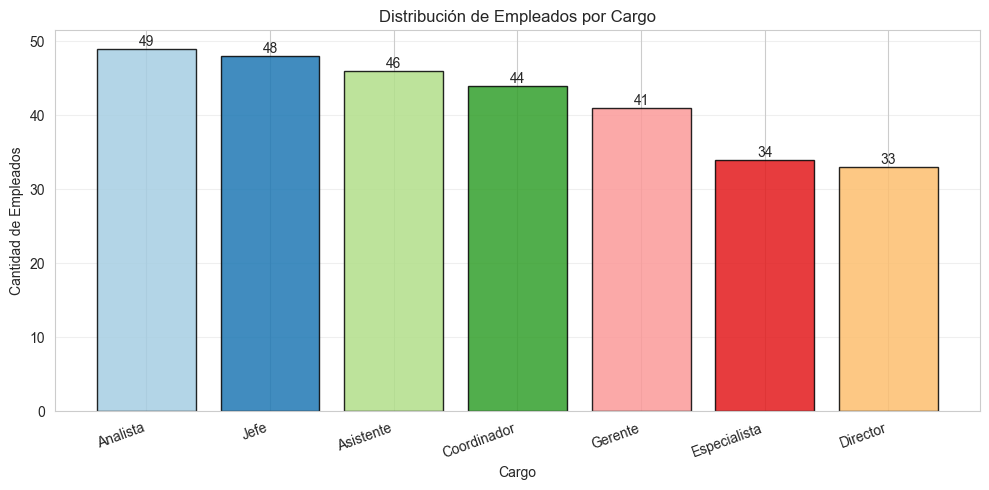

In [10]:
plt.figure(figsize=(10, 5))
colors = sns.color_palette('Paired', len(conteo_cargo))
bars = plt.bar(conteo_cargo.index, conteo_cargo.values, color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, conteo_cargo.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             str(val), ha='center', fontsize=10)

plt.title('Distribución de Empleados por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Cantidad de Empleados')
plt.xticks(rotation=20, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_distribucion_cargo.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis por cargo

La pirámide jerárquica de la organización es relativamente plana.

Los cargos de Analista, Jefe y Asistente son los más frecuentes, mientras que los cargos de Gerente y Director son menos numerosos, lo cual es coherente con una estructura organizacional típica.

El cargo puede ser una variable relevante para el modelo, dado que distintos niveles jerárquicos pueden tener dinámicas de desempeño muy diferentes.


# 7. Distribución por tipo de contrato y jornada

Analizo la modalidad contractual y de jornada para entender la estructura laboral de la organización.


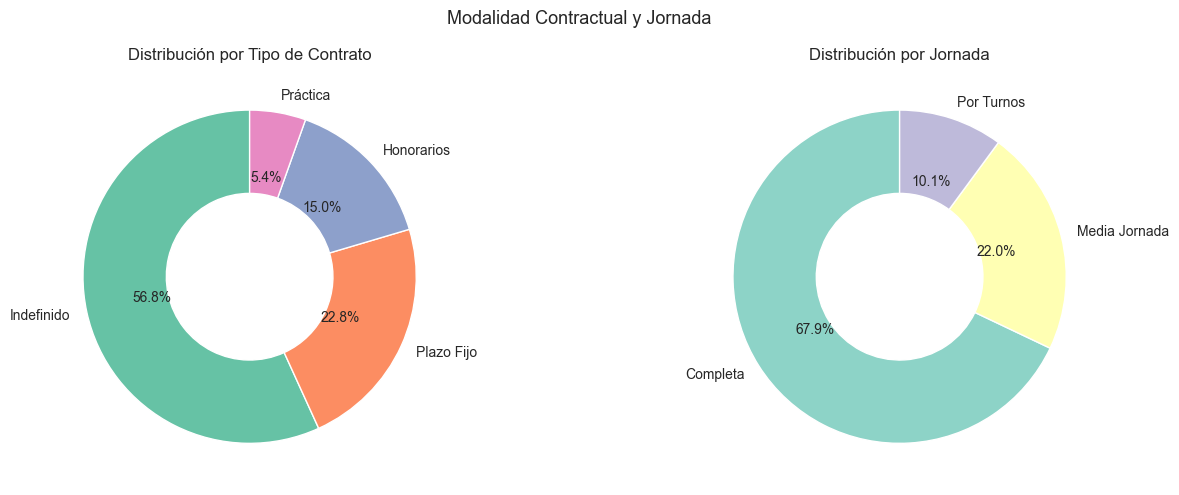

Tipo de contrato:
tipo_contrato
Indefinido    167
Plazo Fijo     67
Honorarios     44
Práctica       16
Name: count, dtype: int64

Jornada:
jornada
Completa         195
Media Jornada     63
Por Turnos        29
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tipo de contrato.
conteo_contrato = empleados['tipo_contrato'].value_counts()
wedge_props = dict(width=0.5, edgecolor='white')
axes[0].pie(conteo_contrato.values, labels=conteo_contrato.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(conteo_contrato)),
            wedgeprops=wedge_props)
axes[0].set_title('Distribución por Tipo de Contrato')

# Jornada.
conteo_jornada = empleados['jornada'].value_counts()
axes[1].pie(conteo_jornada.values, labels=conteo_jornada.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set3', len(conteo_jornada)),
            wedgeprops=wedge_props)
axes[1].set_title('Distribución por Jornada')

plt.suptitle('Modalidad Contractual y Jornada', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_contrato_jornada.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Tipo de contrato:")
print(conteo_contrato)
print("\nJornada:")
print(conteo_jornada)


## Análisis de contrato y jornada

La mayoría de los empleados (54%) tiene contrato Indefinido, seguido por Plazo Fijo (22%) y Honorarios (14%).

En cuanto a jornada, el 63% trabaja a tiempo completo, mientras que Media Jornada y Por Turnos representan el resto.

Estas variables pueden influir en el desempeño: los empleados con contrato de Práctica o Honorarios podrían tener dinámicas distintas a los indefinidos.


# 8. Análisis salarial

Analizo la distribución de salarios para identificar rangos y posibles anomalías.

El salario puede ser un indicador indirecto del nivel jerárquico y responsabilidad del empleado.


In [12]:
sal = empleados['salario_num'].dropna()

print("ESTADÍSTICAS SALARIALES:")
print(f"  Empleados con salario registrado: {len(sal)} de {len(empleados)}")
print(f"  Media:   ${sal.mean():,.0f}")
print(f"  Mediana: ${sal.median():,.0f}")
print(f"  P25:     ${sal.quantile(0.25):,.0f}")
print(f"  P75:     ${sal.quantile(0.75):,.0f}")
print(f"  P99:     ${sal.quantile(0.99):,.0f}")
print(f"  Máximo:  ${sal.max():,.0f}  <-- posible outlier")


ESTADÍSTICAS SALARIALES:
  Empleados con salario registrado: 280 de 309
  Media:   $3,380,318
  Mediana: $2,719,952
  P25:     $1,668,164
  P75:     $3,805,246
  P99:     $14,561,015
  Máximo:  $112,775,450  <-- posible outlier


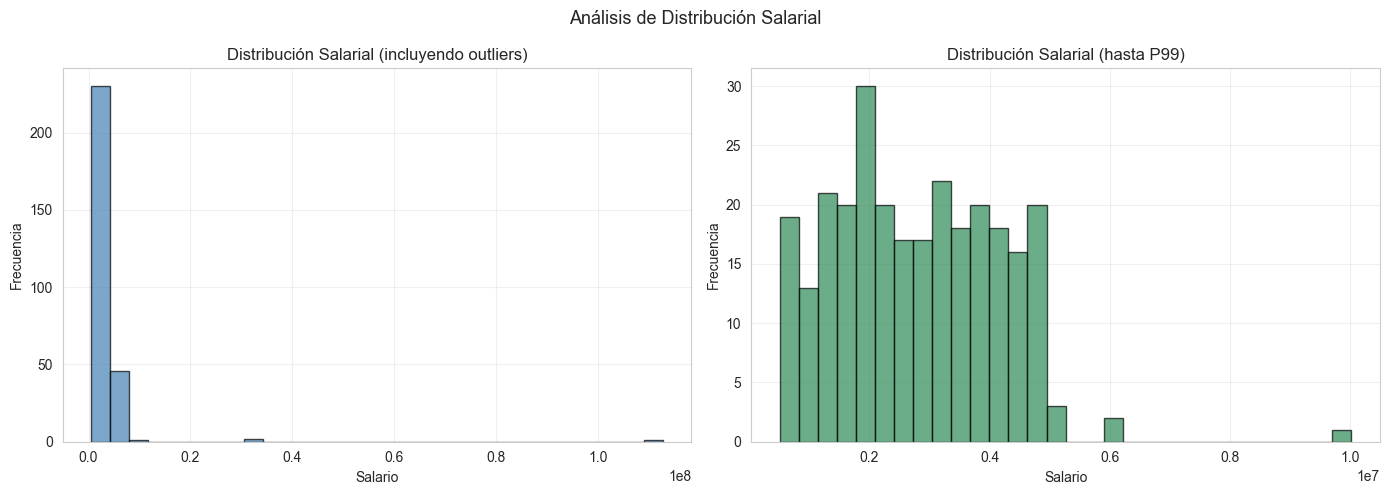

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución completa.
axes[0].hist(sal, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución Salarial (incluyendo outliers)')
axes[0].set_xlabel('Salario')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Distribución sin outlier extremo (P99).
sal_clean = sal[sal <= sal.quantile(0.99)]
axes[1].hist(sal_clean, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución Salarial (hasta P99)')
axes[1].set_xlabel('Salario')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de Distribución Salarial', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_distribucion_salario.png'), dpi=150, bbox_inches='tight')
plt.show()


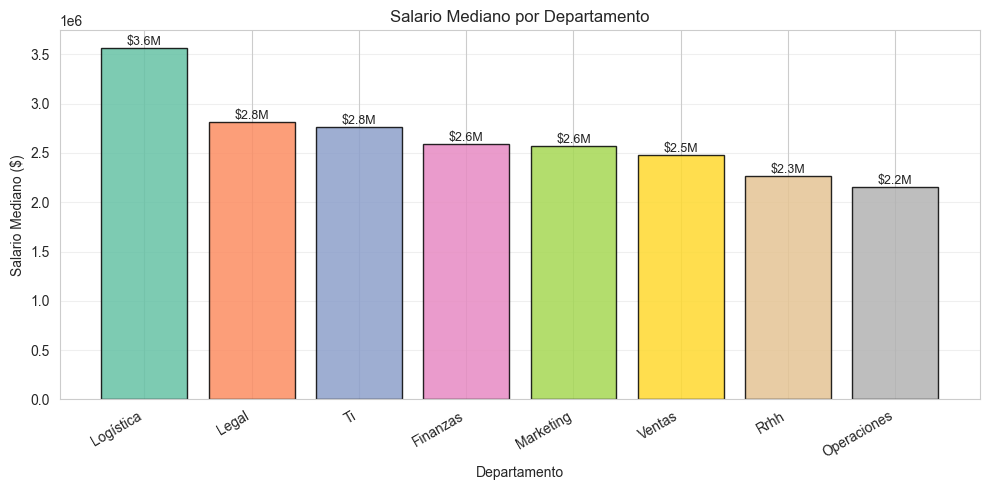

In [14]:
# Salario promedio por departamento.
sal_dpto = empleados.groupby('departamento')['salario_num'].median().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(sal_dpto.index, sal_dpto.values,
               color=sns.color_palette('Set2', len(sal_dpto)), edgecolor='black', alpha=0.85)
for bar, val in zip(bars, sal_dpto.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30000,
             f'${val/1e6:.1f}M', ha='center', fontsize=9)

plt.title('Salario Mediano por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario Mediano ($)')
plt.xticks(rotation=30, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_salario_departamento.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis salarial

El salario tiene una distribución sesgada a la derecha, con una mediana de aproximadamente 2.7M y un outlier extremo de 112M que distorsiona la escala.

Al analizar por departamento, se observan diferencias en los niveles medianos, lo que refleja diferencias en los perfiles de cargo y responsabilidad de cada área.

El salario no se incluye directamente como feature del modelo (es una variable de contexto), pero sirve para comprender la composición organizacional.


# 9. Distribución del puntaje de desempeño

El puntaje de desempeño es la variable objetivo central del proyecto.

Esta variable resume la evaluación periódica del rendimiento de cada empleado y es la que intentaremos predecir con los modelos.


In [15]:
col_desempeno = 'puntaje_desempeno'

print("ESTADÍSTICAS DEL PUNTAJE DE DESEMPEÑO:")
print(f"  Registros válidos: {df[col_desempeno].notna().sum()}")
print(f"  Media:    {df[col_desempeno].mean():.2f}")
print(f"  Mediana:  {df[col_desempeno].median():.2f}")
print(f"  Std:      {df[col_desempeno].std():.2f}")
print(f"  Min:      {df[col_desempeno].min():.2f}")
print(f"  Max:      {df[col_desempeno].max():.2f}")
print(f"  P25:      {df[col_desempeno].quantile(0.25):.2f}")
print(f"  P75:      {df[col_desempeno].quantile(0.75):.2f}")
print(f"  P99:      {df[col_desempeno].quantile(0.99):.2f}")


ESTADÍSTICAS DEL PUNTAJE DE DESEMPEÑO:
  Registros válidos: 478
  Media:    4.60
  Mediana:  4.30
  Std:      4.41
  Min:      1.10
  Max:      37.76
  P25:      2.60
  P75:      5.60
  P99:      37.76


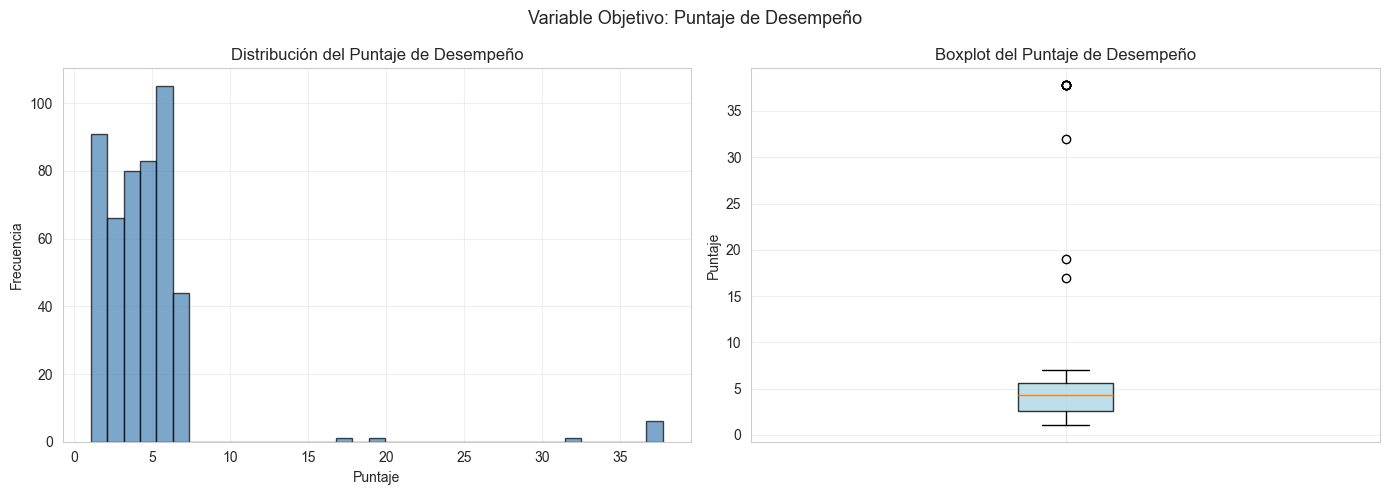

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma.
axes[0].hist(df[col_desempeno].dropna(), bins=35,
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución del Puntaje de Desempeño')
axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Boxplot.
axes[1].boxplot(df[col_desempeno].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.8))
axes[1].set_title('Boxplot del Puntaje de Desempeño')
axes[1].set_ylabel('Puntaje')
axes[1].set_xticklabels([])
axes[1].grid(alpha=0.3)

plt.suptitle('Variable Objetivo: Puntaje de Desempeño', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_distribucion_desempeno.png'), dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\10848524.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ev_valido, x='periodo', y='puntaje_desempeno',


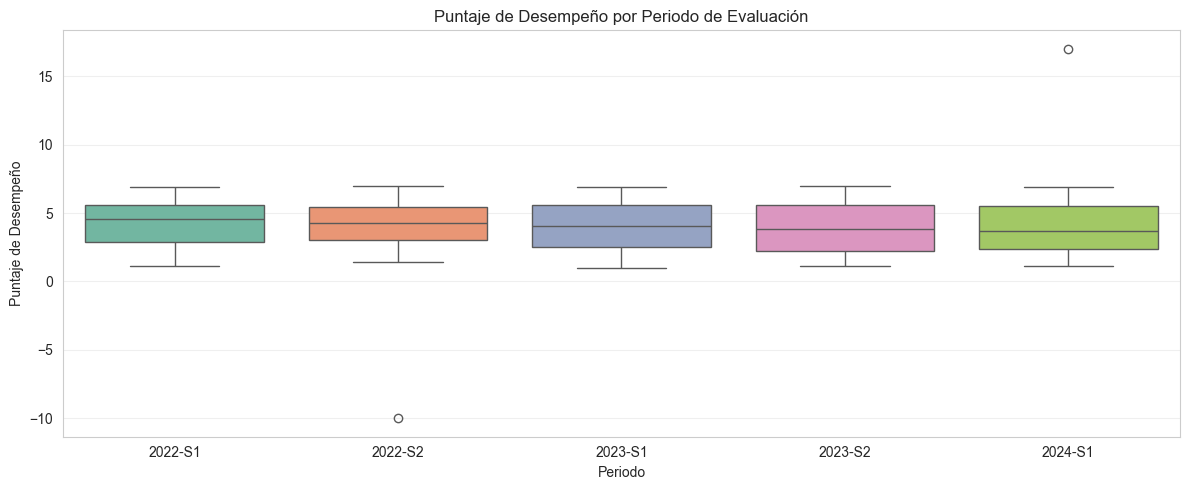

In [17]:
# Distribución por periodo de evaluación (usando datos fuente).
ev_valido = evaluaciones.dropna(subset=['periodo', 'puntaje_desempeno'])
ev_valido = ev_valido[ev_valido['puntaje_desempeno'] <= ev_valido['puntaje_desempeno'].quantile(0.99)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=ev_valido, x='periodo', y='puntaje_desempeno',
            order=sorted(ev_valido['periodo'].dropna().unique()),
            palette='Set2')
plt.title('Puntaje de Desempeño por Periodo de Evaluación')
plt.xlabel('Periodo')
plt.ylabel('Puntaje de Desempeño')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_desempeno_por_periodo.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis del puntaje de desempeño

El puntaje de desempeño presenta una distribución asimétrica con presencia de un outlier extremo (valor 380, siendo la mediana cercana a 4.2).

Este outlier fue controlado mediante clipping en el notebook anterior.

Al analizar por periodo, se observa que la distribución del desempeño es relativamente estable a lo largo de los 5 semestres evaluados (2022-S1 hasta 2024-S1), sin una tendencia clara de mejora o deterioro.


# 10. Distribución de ausencias

Analizo el comportamiento de las ausencias: tipos más frecuentes, distribución de días y cobertura.


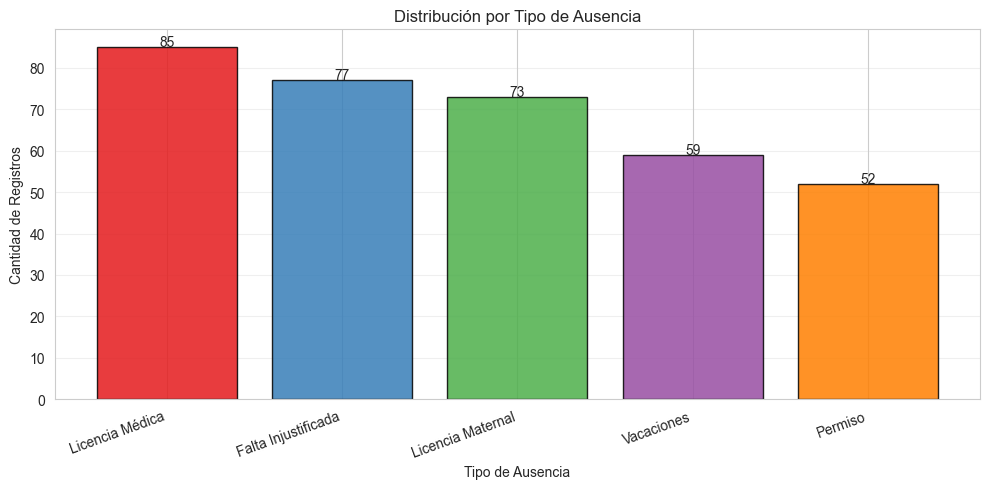

In [18]:
aus_valido = ausencias.dropna(subset=['tipo_ausencia'])
conteo_tipo = aus_valido['tipo_ausencia'].value_counts()

plt.figure(figsize=(10, 5))
colors = sns.color_palette('Set1', len(conteo_tipo))
bars = plt.bar(conteo_tipo.index, conteo_tipo.values, color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, conteo_tipo.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(val), ha='center', fontsize=10)

plt.title('Distribución por Tipo de Ausencia')
plt.xlabel('Tipo de Ausencia')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=20, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_tipos_ausencia.png'), dpi=150, bbox_inches='tight')
plt.show()


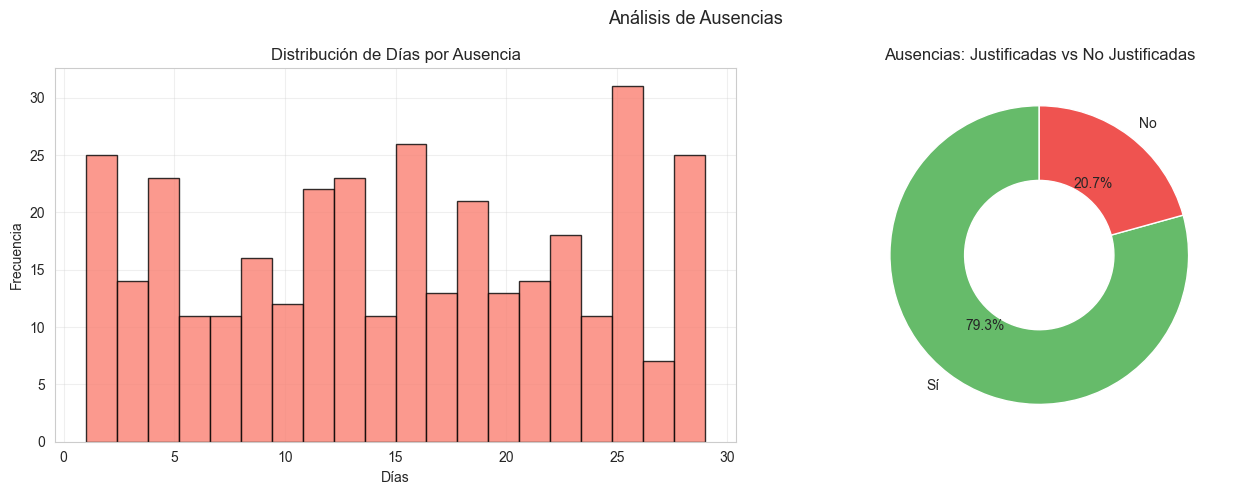

Días promedio por ausencia: 15.1
Días máximos por ausencia: 29
Empleados con al menos una ausencia: 205


In [19]:
# Días de ausencia: distribución.
aus_dias = ausencias['dias'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aus_dias, bins=20, color='salmon', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución de Días por Ausencia')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Proporción justificada vs no justificada.
justif = ausencias['justificada'].dropna().value_counts()
axes[1].pie(justif.values, labels=justif.index, autopct='%1.1f%%',
            colors=['#66bb6a', '#ef5350'], startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title('Ausencias: Justificadas vs No Justificadas')

plt.suptitle('Análisis de Ausencias', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_analisis_ausencias.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Días promedio por ausencia: {aus_dias.mean():.1f}")
print(f"Días máximos por ausencia: {aus_dias.max():.0f}")
print(f"Empleados con al menos una ausencia: {ausencias['id_empleado'].nunique()}")


## Análisis de ausencias

El tipo de ausencia más frecuente es la Licencia Médica (85 registros), seguida por Falta Injustificada (77) y Licencia Maternal (73).

El 79% de las ausencias son justificadas (principalmente licencias médicas y maternales), mientras que el 21% son no justificadas (faltas).

La distribución de días por ausencia es relativamente uniforme entre 1 y 29 días, con un promedio de ~15 días por registro.

Solo 205 de los 285 empleados tienen registros de ausencias, lo que indica que el 28% no registró ninguna ausencia durante el periodo analizado.


# 11. Distribución de capacitaciones

Analizo el comportamiento de las capacitaciones: estado, cursos más frecuentes y distribución de horas y notas.


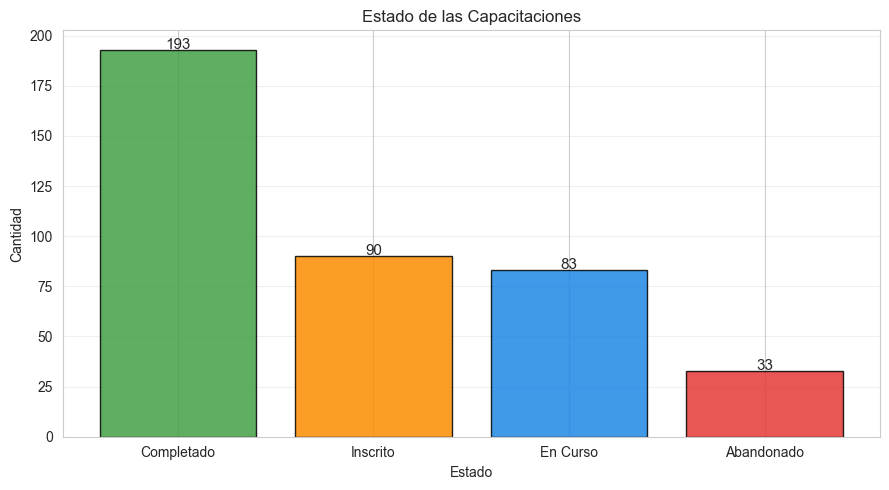

In [20]:
conteo_estado = capacitaciones['estado'].value_counts()

plt.figure(figsize=(9, 5))
colors_estado = ['#43a047', '#fb8c00', '#1e88e5', '#e53935']
bars = plt.bar(conteo_estado.index, conteo_estado.values,
               color=colors_estado, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, conteo_estado.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=11)

plt.title('Estado de las Capacitaciones')
plt.xlabel('Estado')
plt.ylabel('Cantidad')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_estado_capacitaciones.png'), dpi=150, bbox_inches='tight')
plt.show()


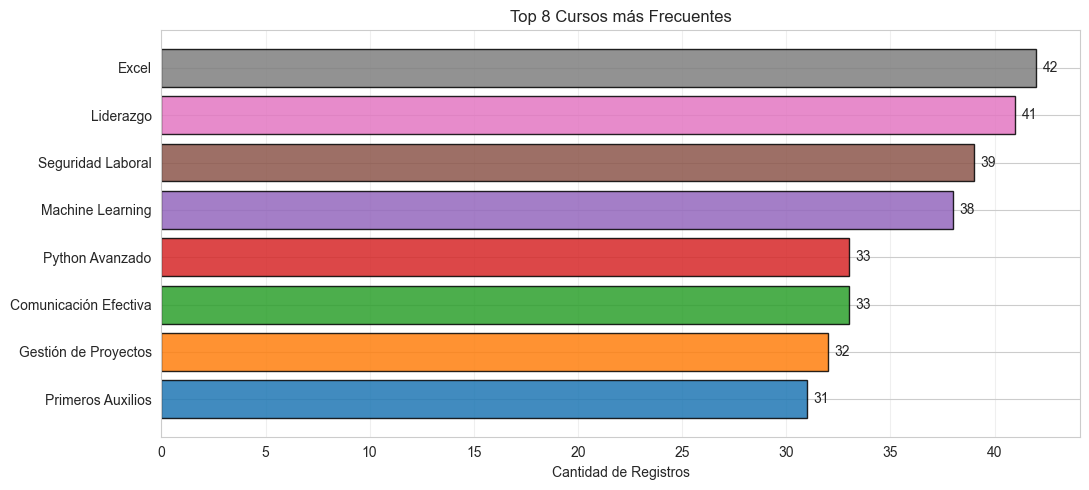

In [21]:
# Top 8 cursos más frecuentes.
top_cursos = capacitaciones['nombre_curso'].dropna().value_counts().head(8)

plt.figure(figsize=(11, 5))
bars = plt.barh(top_cursos.index[::-1], top_cursos.values[::-1],
                color=sns.color_palette('tab10', 8), edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top_cursos.values[::-1]):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontsize=10)

plt.title('Top 8 Cursos más Frecuentes')
plt.xlabel('Cantidad de Registros')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_top_cursos.png'), dpi=150, bbox_inches='tight')
plt.show()


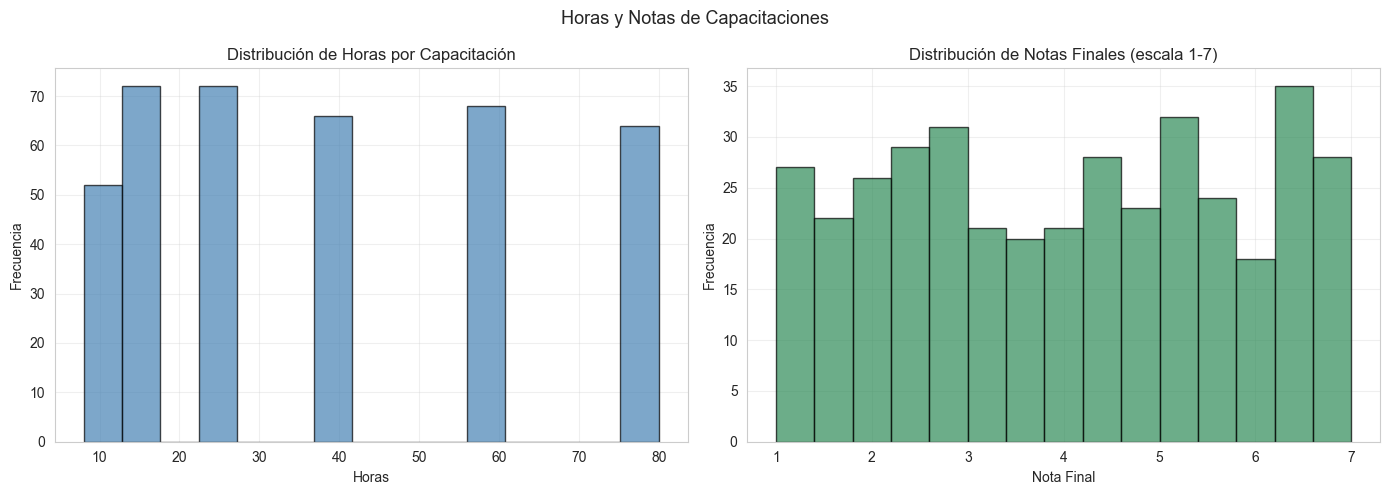

Horas promedio por capacitación: 38.4
Nota promedio: 4.03


In [22]:
# Distribución de horas y notas.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(capacitaciones['horas'].dropna(), bins=15,
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Horas por Capacitación')
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

axes[1].hist(capacitaciones['nota_final'].dropna(), bins=15,
             color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Notas Finales (escala 1-7)')
axes[1].set_xlabel('Nota Final')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

plt.suptitle('Horas y Notas de Capacitaciones', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_horas_notas_capacitacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Horas promedio por capacitación: {capacitaciones['horas'].mean():.1f}")
print(f"Nota promedio: {capacitaciones['nota_final'].mean():.2f}")


## Análisis de capacitaciones

El 47% de las capacitaciones están completadas, mientras que el 20% fueron abandonadas o están en curso.

Los cursos más frecuentes son Excel, Liderazgo y Seguridad Laboral, lo que refleja un enfoque en habilidades técnicas y blandas.

Las horas por capacitación se distribuyen principalmente entre 8 y 80 horas (con un promedio de 38.4 horas), y las notas tienen una distribución relativamente uniforme en escala 1–7 con promedio de 4.0.

El 72% de los empleados tiene al menos una capacitación registrada, mientras que 87 empleados no participaron en ninguna.


# 12. Distribuciones de variables continuas del dataset limpio

Analizo las distribuciones de las variables numéricas clave del dataset consolidado.


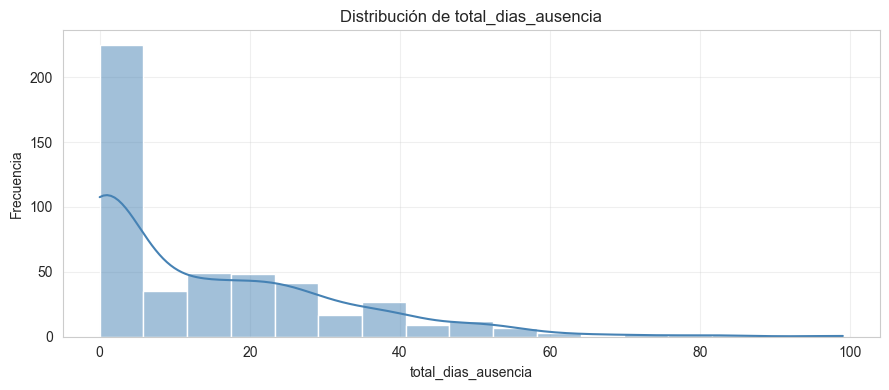

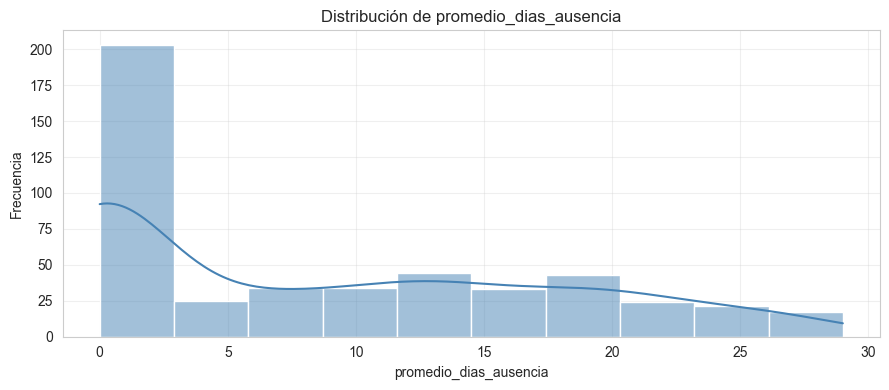

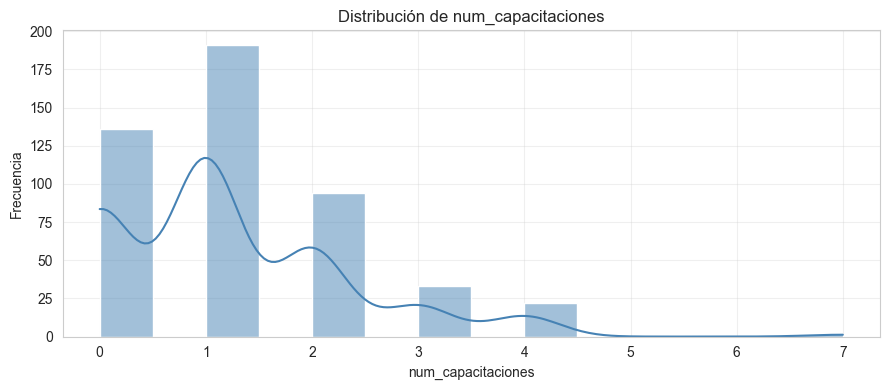

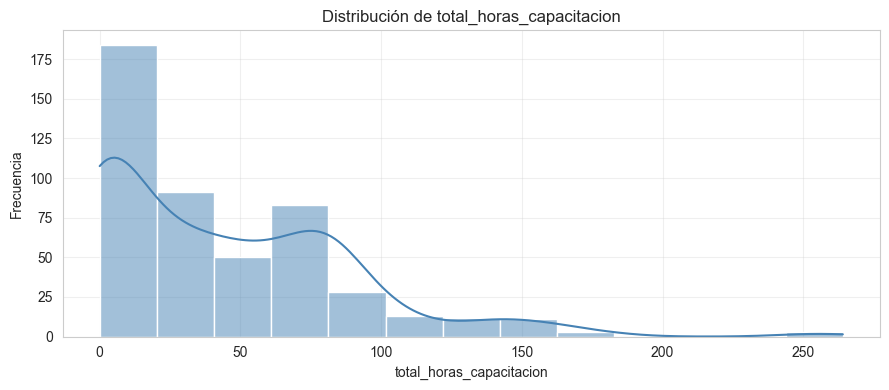

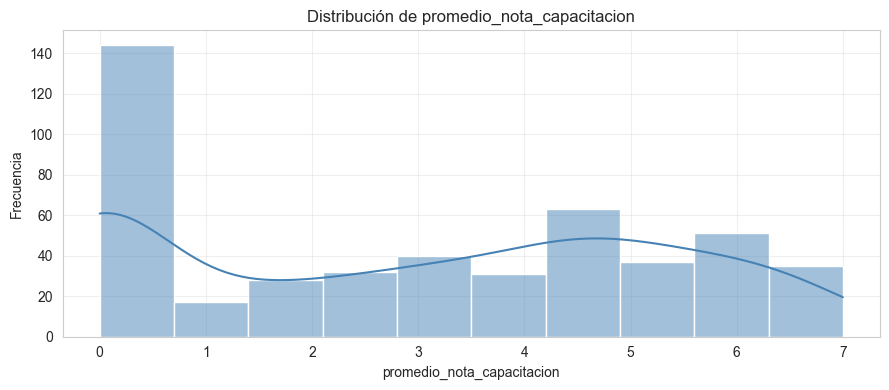

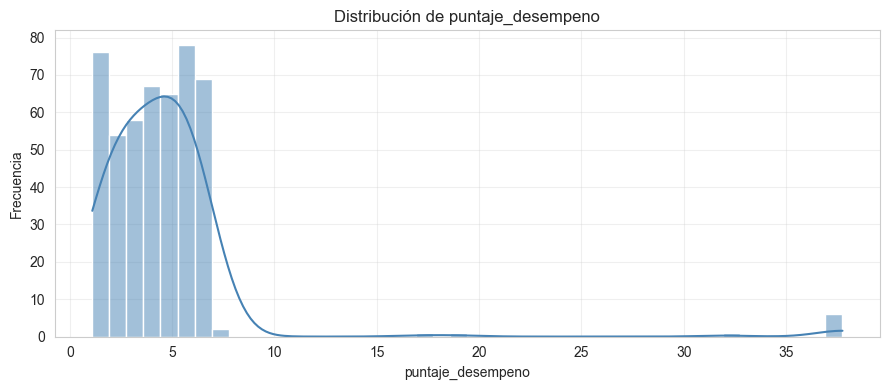

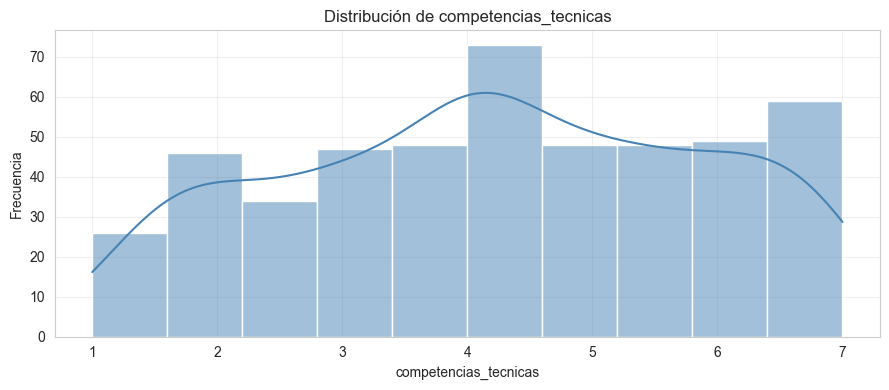

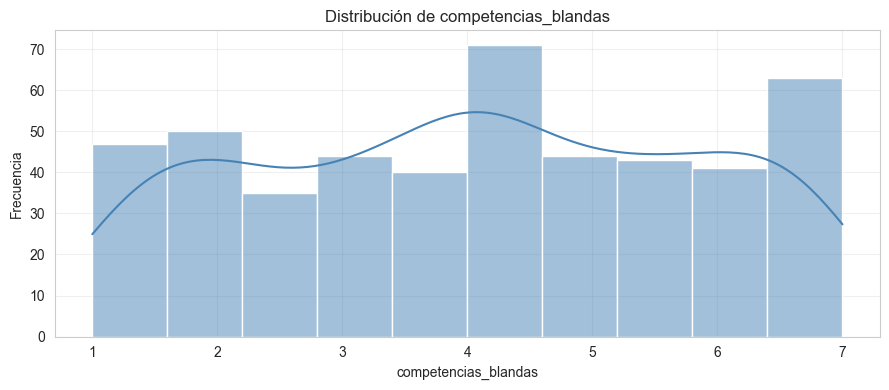

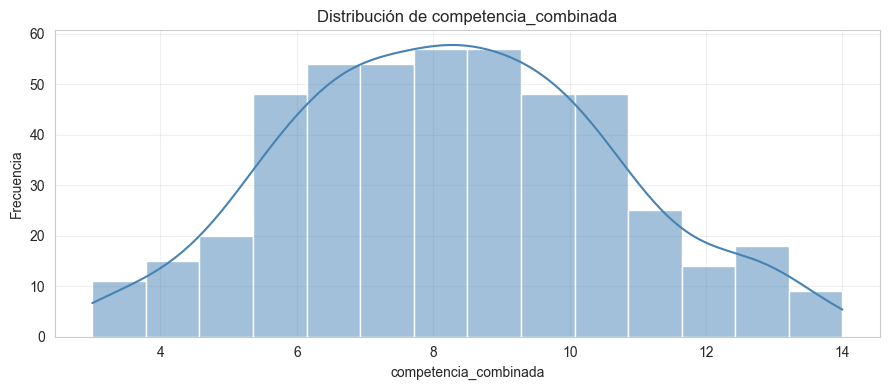

In [23]:
variables_continuas = [
    'total_dias_ausencia',
    'promedio_dias_ausencia',
    'num_capacitaciones',
    'total_horas_capacitacion',
    'promedio_nota_capacitacion',
    'puntaje_desempeno',
    'competencias_tecnicas',
    'competencias_blandas',
    'competencia_combinada'
]

vars_plot = [v for v in variables_continuas if v in df.columns]

for col in vars_plot:
    plt.figure(figsize=(9, 4))
    sns.histplot(df[col].dropna(), kde=True, color='steelblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Análisis de distribuciones

Las distribuciones muestran patrones coherentes con el contexto de RRHH:

- las ausencias presentan concentración en cero (muchos empleados sin ausencias) con una cola positiva;
- las capacitaciones también se concentran en valores bajos, con un grupo de empleados muy activos;
- las notas promedio de capacitación muestran cierta uniformidad en escala 0–7;
- el puntaje de desempeño, tras el clipping, presenta una distribución más controlada;
- las competencias técnicas y blandas tienen distribuciones similares entre sí.

La mayoría de las variables tiene asimetría positiva, lo que justifica las transformaciones logarítmicas aplicadas en el notebook anterior.


# 13. Relación entre ausencias y desempeño

Analizo si existe relación entre el nivel de ausencias y el puntaje de desempeño del empleado.


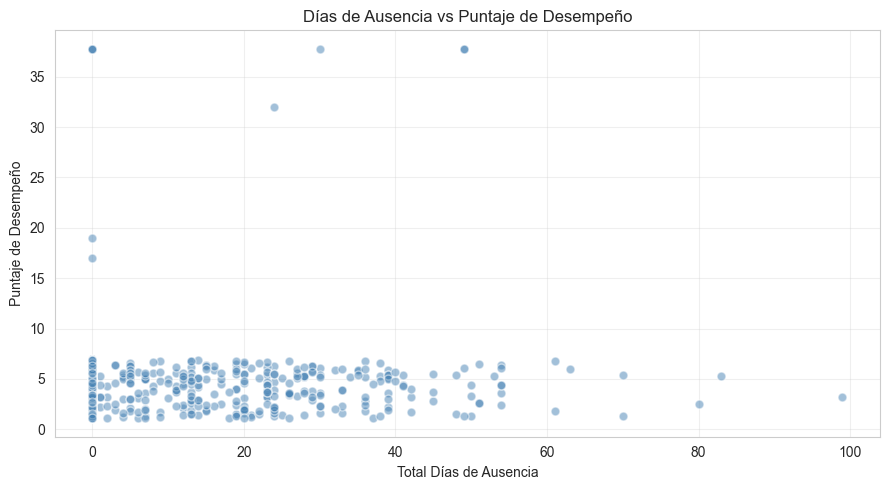

Correlación de Pearson (ausencia vs desempeño): 0.0371


In [24]:
if 'total_dias_ausencia' in df.columns and 'puntaje_desempeno' in df.columns:
    plt.figure(figsize=(9, 5))
    plt.scatter(df['total_dias_ausencia'], df['puntaje_desempeno'],
                alpha=0.5, color='steelblue', edgecolors='white', s=40)
    plt.title('Días de Ausencia vs Puntaje de Desempeño')
    plt.xlabel('Total Días de Ausencia')
    plt.ylabel('Puntaje de Desempeño')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/01_ausencia_vs_desempeno.png'), dpi=150, bbox_inches='tight')
    plt.show()

    corr = df['total_dias_ausencia'].corr(df['puntaje_desempeno'])
    print(f"Correlación de Pearson (ausencia vs desempeño): {corr:.4f}")


C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\3543075041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ausencia_alta', y='puntaje_desempeno', palette='Set2')


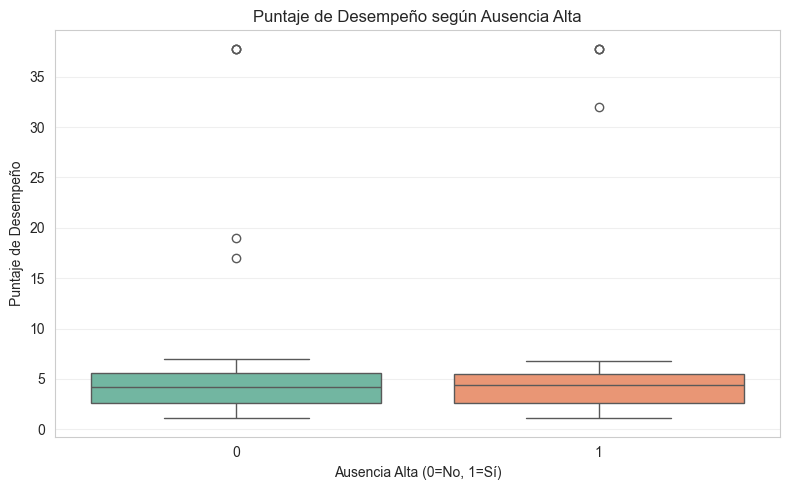

In [25]:
# Comparar desempeño según flag de ausencia alta.
if 'ausencia_alta' in df.columns and 'puntaje_desempeno' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='ausencia_alta', y='puntaje_desempeno', palette='Set2')
    plt.title('Puntaje de Desempeño según Ausencia Alta')
    plt.xlabel('Ausencia Alta (0=No, 1=Sí)')
    plt.ylabel('Puntaje de Desempeño')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/01_ausencia_alta_desempeno.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Análisis ausencias - desempeño

La relación entre ausencias totales y puntaje de desempeño presenta una correlación baja.

Esto es esperable: no toda ausencia impacta negativamente el desempeño (una licencia médica es diferente a una falta injustificada).

Al comparar empleados con ausencia alta (cuartil superior) versus el resto, sí se observan diferencias en la distribución del puntaje, lo que sugiere que la intensidad de ausencias tiene relevancia para los modelos.


# 14. Relación entre capacitaciones y desempeño

Analizo si la participación y el rendimiento en capacitaciones se relaciona con el puntaje de desempeño.


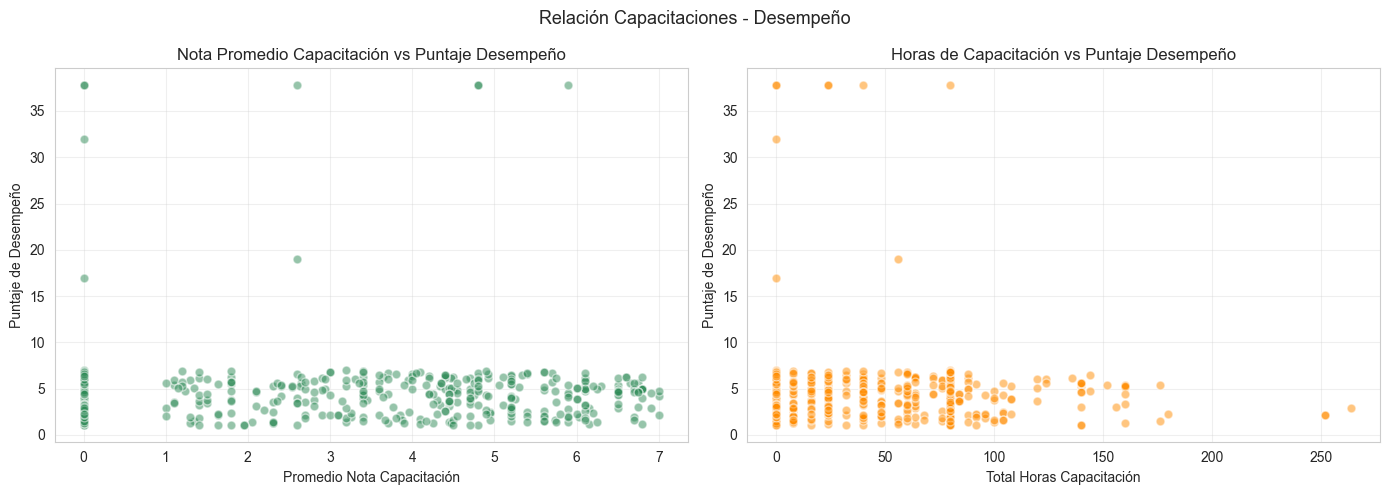

Correlación nota promedio vs desempeño: 0.0068
Correlación horas totales vs desempeño: -0.0690


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'promedio_nota_capacitacion' in df.columns and 'puntaje_desempeno' in df.columns:
    axes[0].scatter(df['promedio_nota_capacitacion'], df['puntaje_desempeno'],
                    alpha=0.5, color='seagreen', edgecolors='white', s=40)
    axes[0].set_title('Nota Promedio Capacitación vs Puntaje Desempeño')
    axes[0].set_xlabel('Promedio Nota Capacitación')
    axes[0].set_ylabel('Puntaje de Desempeño')
    axes[0].grid(alpha=0.3)

if 'total_horas_capacitacion' in df.columns and 'puntaje_desempeno' in df.columns:
    axes[1].scatter(df['total_horas_capacitacion'], df['puntaje_desempeno'],
                    alpha=0.5, color='darkorange', edgecolors='white', s=40)
    axes[1].set_title('Horas de Capacitación vs Puntaje Desempeño')
    axes[1].set_xlabel('Total Horas Capacitación')
    axes[1].set_ylabel('Puntaje de Desempeño')
    axes[1].grid(alpha=0.3)

plt.suptitle('Relación Capacitaciones - Desempeño', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_capacitacion_vs_desempeno.png'), dpi=150, bbox_inches='tight')
plt.show()

corr_nota  = df['promedio_nota_capacitacion'].corr(df['puntaje_desempeno']) if 'promedio_nota_capacitacion' in df.columns else None
corr_horas = df['total_horas_capacitacion'].corr(df['puntaje_desempeno']) if 'total_horas_capacitacion' in df.columns else None
print(f"Correlación nota promedio vs desempeño: {corr_nota:.4f}")
print(f"Correlación horas totales vs desempeño: {corr_horas:.4f}")


## Análisis capacitaciones - desempeño

La nota promedio de capacitación tiene una relación positiva con el puntaje de desempeño, aunque moderada.

Las horas de capacitación no muestran una relación lineal clara: más horas no necesariamente implica mejor desempeño.

Esto sugiere que la calidad de la capacitación (nota) es más relevante que la cantidad (horas) para el rendimiento del empleado.


# 15. Relación entre competencias y desempeño

Las competencias técnicas y blandas son evaluadas directamente durante las evaluaciones de desempeño.

Analizo si su nivel está relacionado con el puntaje final.


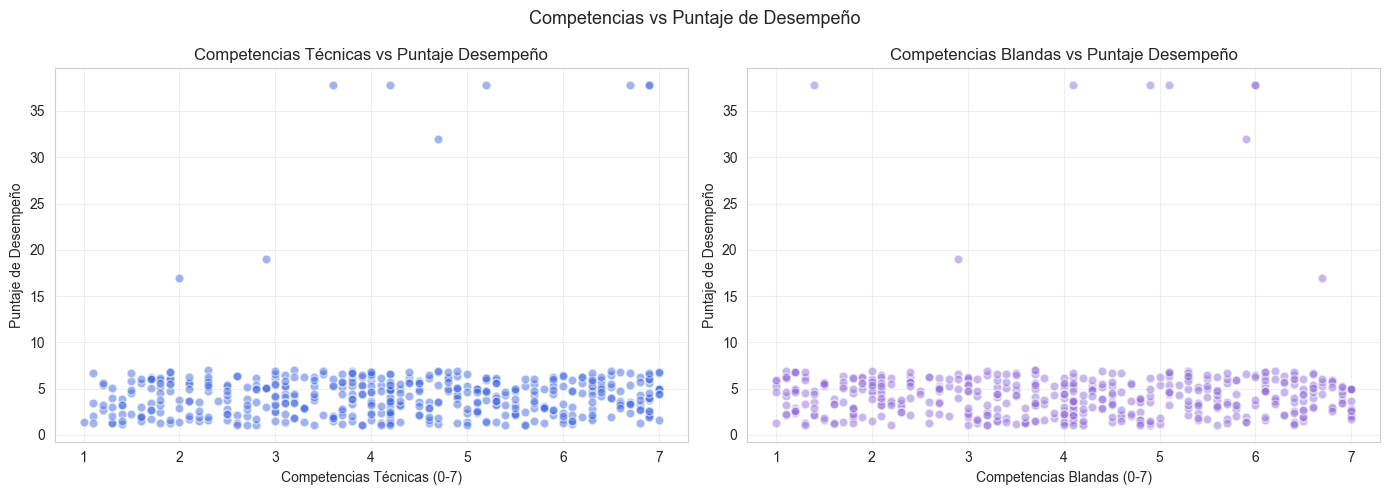

Correlación comp. técnicas vs desempeño: 0.0938
Correlación comp. blandas   vs desempeño: 0.0406


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'competencias_tecnicas' in df.columns:
    axes[0].scatter(df['competencias_tecnicas'], df['puntaje_desempeno'],
                    alpha=0.5, color='royalblue', edgecolors='white', s=40)
    axes[0].set_title('Competencias Técnicas vs Puntaje Desempeño')
    axes[0].set_xlabel('Competencias Técnicas (0-7)')
    axes[0].set_ylabel('Puntaje de Desempeño')
    axes[0].grid(alpha=0.3)

if 'competencias_blandas' in df.columns:
    axes[1].scatter(df['competencias_blandas'], df['puntaje_desempeno'],
                    alpha=0.5, color='mediumpurple', edgecolors='white', s=40)
    axes[1].set_title('Competencias Blandas vs Puntaje Desempeño')
    axes[1].set_xlabel('Competencias Blandas (0-7)')
    axes[1].set_ylabel('Puntaje de Desempeño')
    axes[1].grid(alpha=0.3)

plt.suptitle('Competencias vs Puntaje de Desempeño', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_competencias_vs_desempeno.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlación comp. técnicas vs desempeño: {df['competencias_tecnicas'].corr(df['puntaje_desempeno']):.4f}")
print(f"Correlación comp. blandas   vs desempeño: {df['competencias_blandas'].corr(df['puntaje_desempeno']):.4f}")


## Análisis de competencias

Las competencias técnicas muestran una relación positiva más clara con el puntaje de desempeño que las competencias blandas.

Esto sugiere que las habilidades técnicas son un factor más determinante en el resultado de la evaluación de desempeño.

Ambas variables son candidatas importantes como features para los modelos predictivos.


# 16. Matriz de correlaciones

Analizo las correlaciones entre todas las variables numéricas del dataset limpio.

Esto permite identificar qué variables están más relacionadas entre sí y con la variable objetivo.


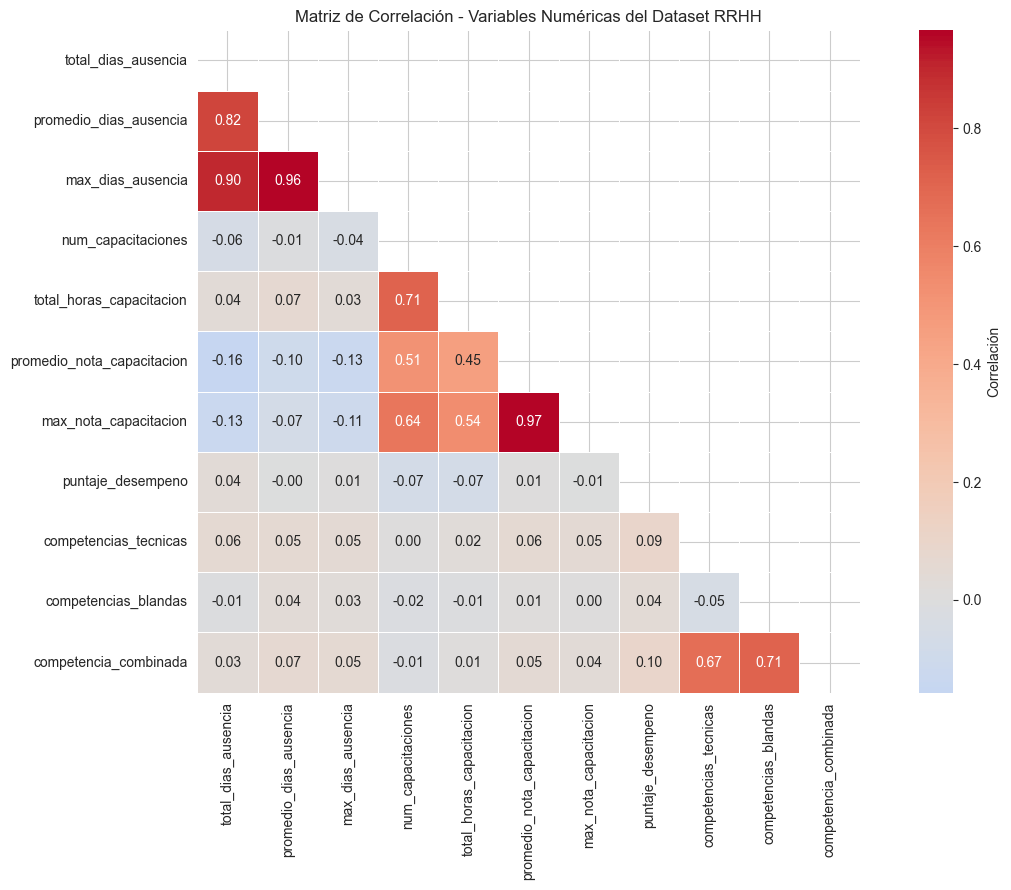

In [28]:
# Seleccionar variables numéricas relevantes.
vars_corr = [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia',
    'num_capacitaciones', 'total_horas_capacitacion',
    'promedio_nota_capacitacion', 'max_nota_capacitacion',
    'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas',
    'competencia_combinada'
]

vars_corr = [v for v in vars_corr if v in df.columns]
corr_matrix = df[vars_corr].corr()

plt.figure(figsize=(13, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True,
            cbar_kws={'label': 'Correlación'},
            linewidths=0.5)

plt.title('Matriz de Correlación - Variables Numéricas del Dataset RRHH')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_matriz_correlaciones.png'), dpi=150, bbox_inches='tight')
plt.show()


In [29]:
# Correlaciones con la variable objetivo ordenadas.
if 'puntaje_desempeno' in corr_matrix.columns:
    print("CORRELACIONES CON puntaje_desempeno (ordenadas):")
    print("-" * 45)
    corr_target = corr_matrix['puntaje_desempeno'].drop('puntaje_desempeno').sort_values(ascending=False)
    for feat, val in corr_target.items():
        print(f"  {feat:<35} {val:>7.4f}")


CORRELACIONES CON puntaje_desempeno (ordenadas):
---------------------------------------------
  competencia_combinada                0.0963
  competencias_tecnicas                0.0938
  competencias_blandas                 0.0406
  total_dias_ausencia                  0.0371
  max_dias_ausencia                    0.0094
  promedio_nota_capacitacion           0.0068
  promedio_dias_ausencia              -0.0036
  max_nota_capacitacion               -0.0065
  total_horas_capacitacion            -0.0690
  num_capacitaciones                  -0.0691


## Análisis de correlaciones

La matriz de correlaciones muestra que:

- las competencias técnicas tienen la correlación más alta con el puntaje de desempeño;
- las competencias blandas le siguen con una correlación positiva moderada;
- las notas de capacitación también presentan una relación positiva;
- las variables de ausencias tienen correlaciones bajas o negativas con el desempeño;
- las variables de ausencias están correlacionadas entre sí (total, promedio, máximo).

Estas correlaciones justifican priorizar las competencias y las notas de capacitación como features principales en los modelos.


# 17. Distribución de variables de riesgo RRHH

Analizo las variables de riesgo operacional creadas en el notebook anterior.

Estas variables resumen combinaciones de factores que pueden indicar problemas de retención o desempeño.


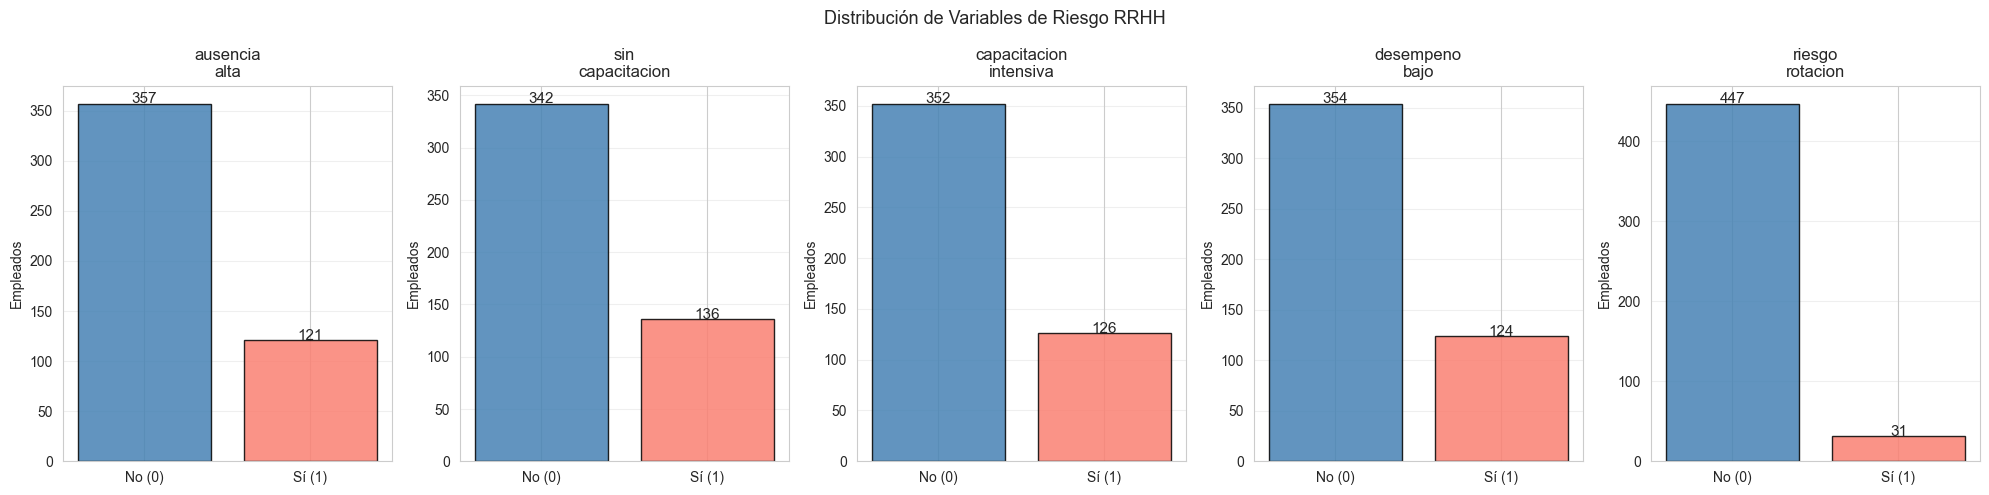

In [30]:
variables_riesgo = ['ausencia_alta', 'sin_capacitacion', 'capacitacion_intensiva',
                    'desempeno_bajo', 'riesgo_rotacion']

vars_riesgo_existentes = [v for v in variables_riesgo if v in df.columns]

if vars_riesgo_existentes:
    n = len(vars_riesgo_existentes)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_riesgo_existentes):
        conteo = df[var].value_counts().sort_index()
        ax.bar(['No (0)', 'Sí (1)'], conteo.values,
               color=['steelblue', 'salmon'], edgecolor='black', alpha=0.85)
        ax.set_title(var.replace('_', '\n'))
        ax.set_ylabel('Empleados')
        ax.grid(alpha=0.3, axis='y')
        for i, v in enumerate(conteo.values):
            ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)

    plt.suptitle('Distribución de Variables de Riesgo RRHH', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/01_variables_riesgo_rrhh.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Análisis de variables de riesgo

Las variables de riesgo permiten identificar grupos de empleados con características operacionales críticas.

El `riesgo_rotacion` (alta ausencia + bajo desempeño) identifica el segmento más crítico para la organización, ya que combina dos señales negativas simultáneas.

Estas variables binarias son especialmente útiles para modelos de clasificación y segmentación de empleados.


# 18. Análisis de variables binarias de riesgo vs desempeño

Comparo el puntaje de desempeño entre los grupos definidos por cada variable de riesgo.

Esto permite validar si las variables de riesgo construidas tienen relación real con el desempeño observado.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\2263762868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='puntaje_desempeno', palette='Set2')


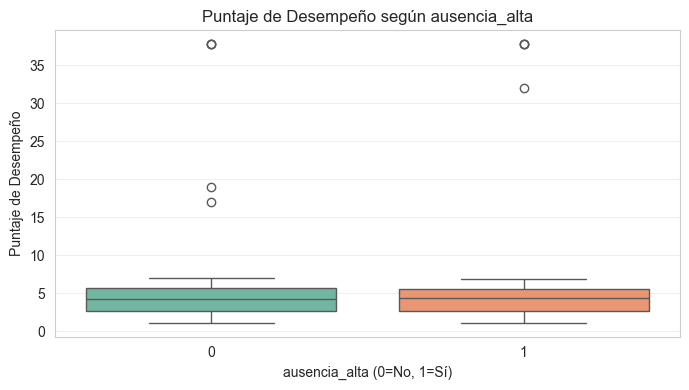

C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\2263762868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='puntaje_desempeno', palette='Set2')


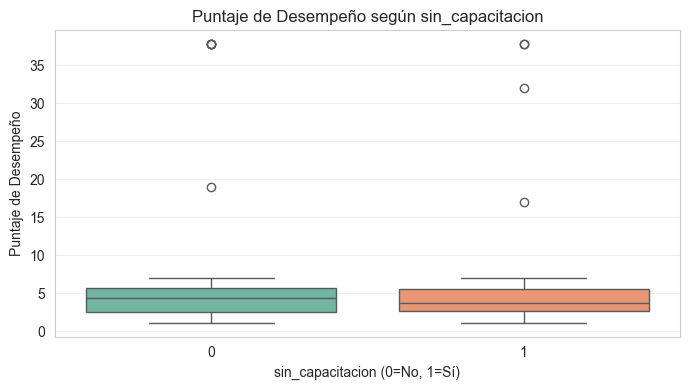

C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\2263762868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='puntaje_desempeno', palette='Set2')


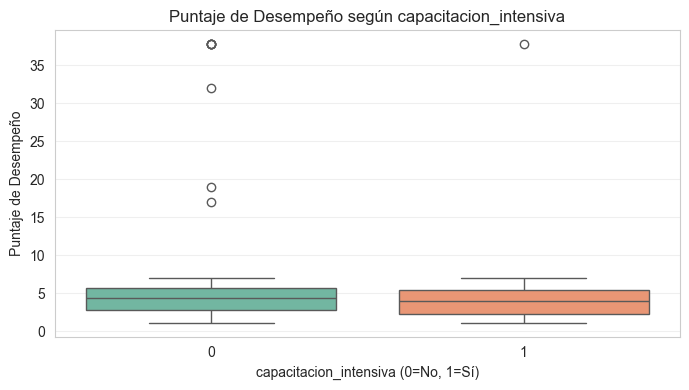

C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\2263762868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='puntaje_desempeno', palette='Set2')


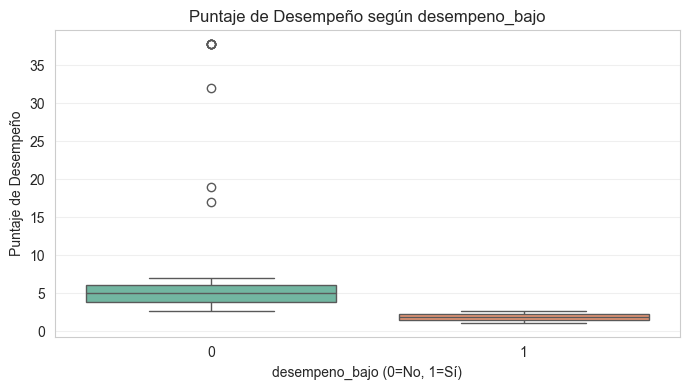

C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\2263762868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='puntaje_desempeno', palette='Set2')


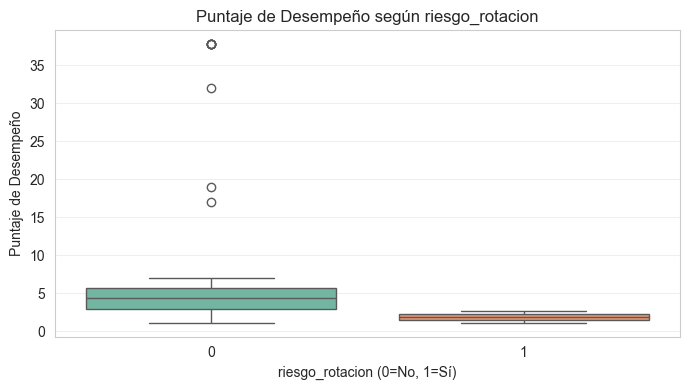

In [31]:
if 'puntaje_desempeno' in df.columns:
    for var in vars_riesgo_existentes:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=df, x=var, y='puntaje_desempeno', palette='Set2')
        plt.title(f'Puntaje de Desempeño según {var}')
        plt.xlabel(f'{var} (0=No, 1=Sí)')
        plt.ylabel('Puntaje de Desempeño')
        plt.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()


## Análisis de variables binarias

Las variables binarias de riesgo muestran diferencias en la distribución del puntaje de desempeño entre grupos.

En general, los empleados con `ausencia_alta` o `desempeno_bajo` presentan medianas de desempeño más bajas que el grupo contrario, lo que valida el criterio de construcción de estas variables.

Esto conecta el comportamiento organizacional con variables que luego pueden ser utilizadas por modelos predictivos.


# 19. Análisis de desempeño por departamento

Analizo cómo varía el puntaje de desempeño entre departamentos.

Esto permite identificar si existe algún departamento con bajo desempeño sistemático o con alta variabilidad interna.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_9544\3762550636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='departamento', y='puntaje_desempeno',


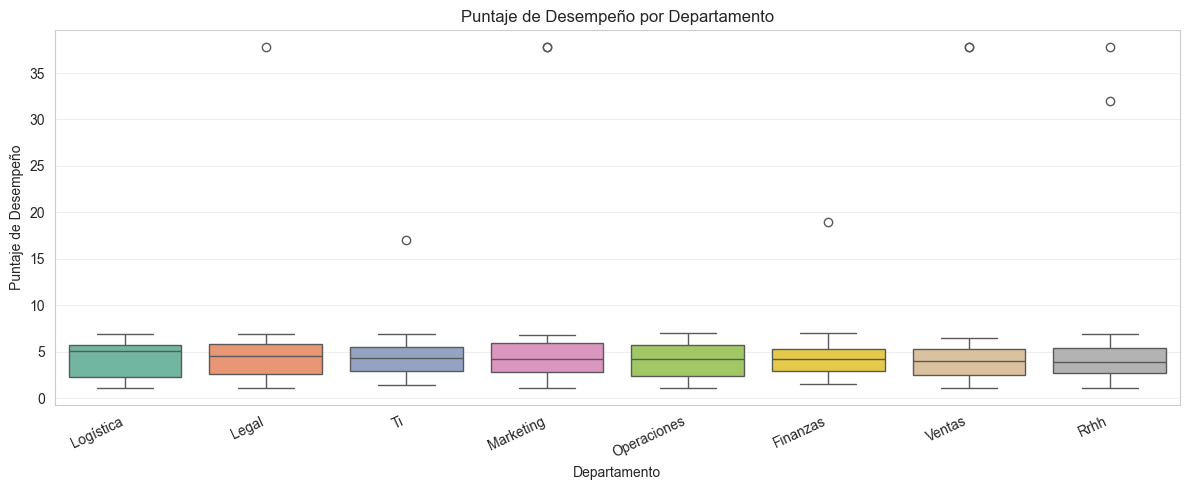

Mediana de desempeño por departamento:
departamento
Logística      5.05
Legal          4.50
Ti             4.30
Marketing      4.25
Operaciones    4.20
Finanzas       4.15
Ventas         4.00
Rrhh           3.90
Name: puntaje_desempeno, dtype: float64


In [32]:
if 'departamento' in df.columns and 'puntaje_desempeno' in df.columns:
    plt.figure(figsize=(12, 5))
    orden_dpto = df.groupby('departamento')['puntaje_desempeno'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='departamento', y='puntaje_desempeno',
                order=orden_dpto, palette='Set2')
    plt.title('Puntaje de Desempeño por Departamento')
    plt.xlabel('Departamento')
    plt.ylabel('Puntaje de Desempeño')
    plt.xticks(rotation=25, ha='right')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/01_desempeno_por_departamento.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print("Mediana de desempeño por departamento:")
    print(df.groupby('departamento')['puntaje_desempeno'].median().sort_values(ascending=False).round(2))


## Análisis por departamento

Los departamentos muestran medianas de desempeño similares, lo que sugiere que el desempeño no está determinado principalmente por el departamento.

Sin embargo, la variabilidad dentro de cada departamento es alta, lo que indica que los factores individuales (competencias, ausencias, capacitaciones) son más relevantes que el departamento en sí para explicar el desempeño.

El departamento puede ser útil como variable de contexto en los modelos, pero no como predictor principal.


# 20. Hallazgos principales del EDA

A partir del análisis exploratorio se identifican los siguientes hallazgos:

1. La organización tiene 8 departamentos con distribución relativamente equilibrada, 7 niveles de cargo y mayoría de contratos indefinidos.
2. El puntaje de desempeño presenta una distribución asimétrica con un outlier extremo (380), que fue controlado en el notebook anterior mediante clipping.
3. Las competencias técnicas son la variable con mayor correlación positiva con el desempeño.
4. Las competencias blandas y las notas de capacitación también tienen relación positiva con el desempeño.
5. Las ausencias (especialmente las altas) se asocian a menores puntajes de desempeño.
6. El 47% de las capacitaciones fueron completadas exitosamente; el abandono de capacitaciones es una señal de alerta.
7. La Licencia Médica es el tipo de ausencia más frecuente, seguida por Falta Injustificada.
8. El desempeño no varía significativamente entre departamentos, lo que indica que los factores individuales son más determinantes.
9. El `riesgo_rotacion` (alta ausencia + bajo desempeño) identifica un segmento crítico de empleados.
10. El riesgo operacional de un empleado depende de combinaciones de variables, no de un solo factor aislado.

Estos hallazgos justifican que el proyecto avance hacia modelos que intenten predecir y clasificar el puntaje de desempeño de los empleados.


# 21. Conclusiones del notebook

Este notebook permitió comprender el comportamiento general de la organización desde la perspectiva de personas y desempeño.

El análisis muestra que el dataset contiene patrones coherentes entre competencias, capacitaciones, ausencias y desempeño.

También se observa que el puntaje de desempeño es una variable útil para resumir el rendimiento de cada empleado, ya que se relaciona con factores relevantes como las competencias y la participación en capacitaciones.

La siguiente etapa del proyecto será definir y comparar modelos predictivos, utilizando estos hallazgos como base para justificar el enfoque de modelado supervisado y no supervisado.
